In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
data = pd.read_csv("/content/Salary_dataset.csv")

data.head()

,YearsExperience,Salary
0,1.2,39344
1,1.4,46206
2,1.6,37732
3,2.1,43526
4,2.3,39892


In [6]:
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None
YearsExperience    0
Salary             0
dtype: int64


In [7]:
X = data[["YearsExperience"]]
y = data["Salary"]

print(X.head())
print(y.head())

   YearsExperience
0              1.2
1              1.4
2              1.6
3              2.1
4              2.3
0    39344
1    46206
2    37732
3    43526
4    39892
Name: Salary, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
dt_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

In [10]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [11]:
y_pred = dt_model.predict(X_test)

print(y_pred)

[120411.66666667  66030.          96314.25        66030.
  58175.75        58175.75      ]


In [12]:
result = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

result

,Actual Salary,Predicted Salary
0,112636,120411.666667
1,67939,66030.000000
2,113813,96314.250000
3,83089,66030.000000
4,64446,58175.750000
5,57190,58175.750000


In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 8583.069444444445
Mean Squared Error: 116934790.63310187
R2 Score: 0.7710733765566314


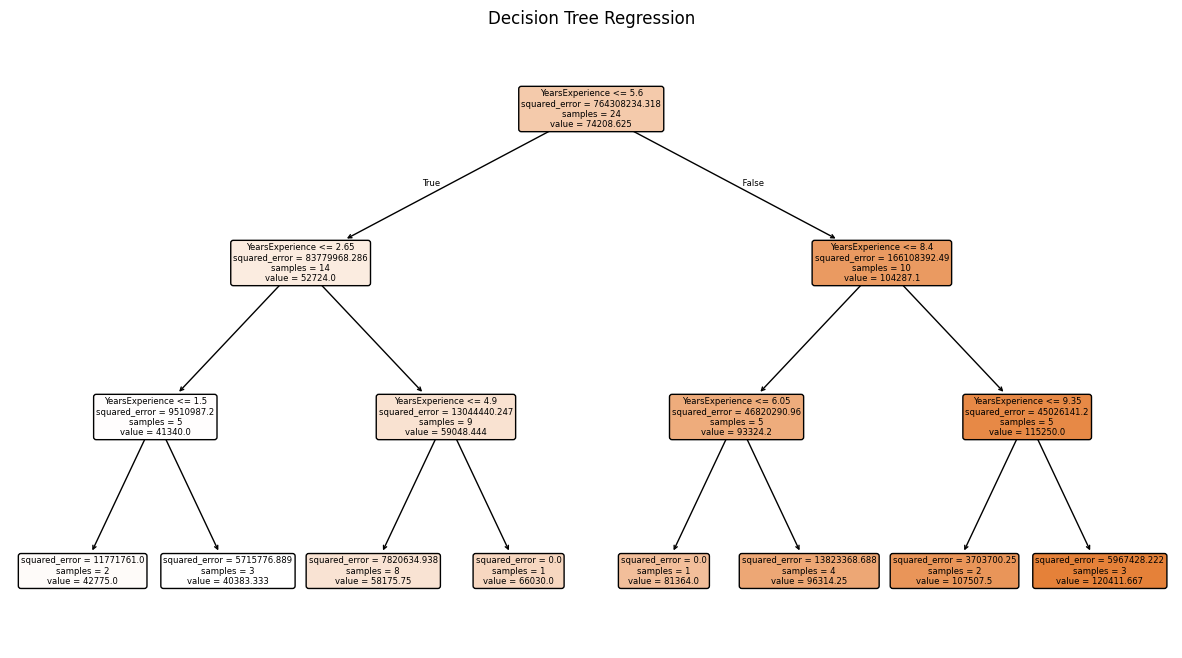

In [14]:
plt.figure(figsize=(15, 8))

plot_tree(
    dt_model,
    feature_names=["YearsExperience"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Regression")
plt.show()

In [15]:
new_data = pd.DataFrame({
    "YearsExperience": [5.0]
})

predicted_salary = dt_model.predict(new_data)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 66030.0


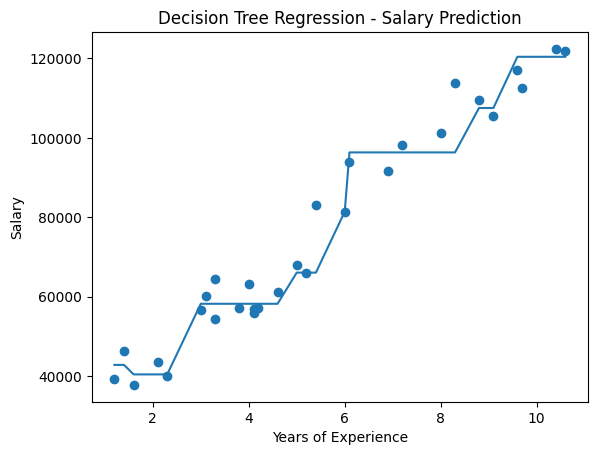

In [16]:
X_sorted = X.sort_values("YearsExperience")

plt.scatter(X["YearsExperience"], y)
plt.plot(
    X_sorted["YearsExperience"],
    dt_model.predict(X_sorted)
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Decision Tree Regression - Salary Prediction")
plt.show()